In [2]:
#-----------------------------
# Packages Import
#-----------------------------
%matplotlib inline


import numpy as np
from matplotlib import pyplot as plt

# Used to handle picture drawings
import cv2

# Used Handle directories and paths
import os

# Used to create and compute random angles
import random
import math

# Used to create the image labels
import json



In [3]:
#--------------------------
# Constants across the project
#----------------------------

# Mapping cardinal directions to approximate angles (in radians)
# Starting N at -90 degrees (standard Cartesian setup in image space)
DIRECTIONS = {
    "N":  -math.pi/2, "NE": -math.pi/4, "E": 0, "SE": math.pi/4,
    "S":   math.pi/2, "SW": 3*math.pi/4, "W": math.pi, "NW": -3*math.pi/4
}

DIRECTIONS_NUMBER= {
    "N":  1, "NE": 2, "E": 3, "SE": 4,
    "S":   5, "SW": 6, "W": 7, "NW": 8
}


DIR_KEYS = list(DIRECTIONS.keys())


In [72]:
#------------------------
#Basic Drawing functions:
#-----------------------

def get_boundary_point(angle, size):
    """Calculates where a line at 'angle' hits the image boundary."""
    h, w = size
    cx, cy = w // 2, h // 2
    
    # Large distance to ensure we hit the boundary
    dist = max(w, h)
    
    x1 = int(cx - dist * math.cos(angle))
    y1 = int(cy - dist * math.sin(angle))
    x2 = int(cx + dist * math.cos(angle))
    y2 = int(cy + dist * math.sin(angle))
    
    _,p1,p2 = cv2.clipLine((0, 0, w, h), (x1, y1), (x2, y2))
    return [p1,p2] 


#This function Draws a line going through the center given the angle
def draw_strand(img, angle, thickness, isMain):
    h, w = img.shape[:2]
    cx, cy = w // 2, h // 2
    
    p_in, p_out= get_boundary_point(angle, (h, w))
    
    cv2.line(img, p_in, p_out, (0,0,0), thickness, cv2.LINE_AA)
    if isMain: cv2.circle(img,p_in, 10, (0,0,0), -1)
    
    return None



#This function Draws an overline line going through the center given the angle


def draw_over_strand(img, angle, thickness, space_bewteen_strands, isMain):
    h, w = img.shape[:2]
    cx, cy = w // 2, h // 2
    
    p_in, p_out= get_boundary_point(angle, (h, w))
    
    cv2.line(img, p_in, p_out, (255,255,255), thickness+space_bewteen_strands, cv2.LINE_AA)
    cv2.line(img, p_in, p_out, (0,0,0), thickness, cv2.LINE_AA)
    if isMain: cv2.circle(img,p_in, 10, (0,0,0), -1)
    return None


In [83]:
#------------------
# Advanced drawing functions
#------------------


#------------------
# Constants
#----------------------
WINDOW_SIZE = (64, 64) 
THICKNESS = 2
SPACE_BEWTEEN_STRANDS=8

#--------------------------------------------
# Drawing functions
#-----------------------------------------
def draw_Straight_Line(direction):
    #Randomize the main direction
    angle = DIRECTIONS[DIR_KEYS[direction]]+ random.uniform(-1, 1)*math.pi/16
    draw_strand(img, angle, THICKNESS  * 2, True)
    return None


def draw_over_crossing(direction1, direction2):

    #Randomize a small tilt of the main picture
    angle1 = DIRECTIONS[DIR_KEYS[(direction1 + 2) % 8]]+ random.uniform(-1, 1)*math.pi/16
    angle2 = DIRECTIONS[DIR_KEYS[(direction2 + 2) % 8]]+ random.uniform(-1, 1)*math.pi/16

    # Draw secondary strand FIRST (it goes underneath)
    draw_strand(img, angle2, THICKNESS  * 2, False)
    # Draw primary strand SECOND (it goes on top)
    draw_over_strand(img, angle1, THICKNESS  * 2, SPACE_BEWTEEN_STRANDS, True)

    return None


def draw_under_crossing(direction1, direction2):
        #Randomize a small tilt of the main picture
    angle1 = DIRECTIONS[DIR_KEYS[(direction1 + 2) % 8]]+ random.uniform(-1, 1)*math.pi/16
    angle2 = DIRECTIONS[DIR_KEYS[(direction2 + 2) % 8]]+ random.uniform(-1, 1)*math.pi/16

    # Draw primary strand FIRST (it goes underneath)
    draw_strand(img, angle1, THICKNESS  * 2, True)
    # Draw secondart strand SECOND (it goes on top)
    draw_over_strand(img, angle2, THICKNESS  * 2, SPACE_BEWTEEN_STRANDS, False)

    return None

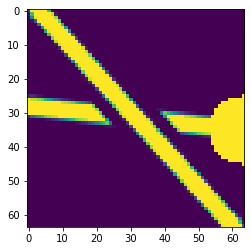

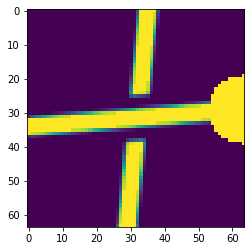

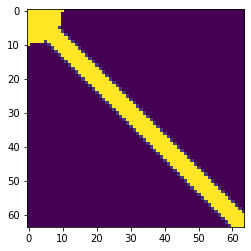

In [84]:
#-------------------------------
# Small cell that generates 5 random corssing
#-------------------------------

N=3

for i in range(N):
    # Initialize a clean, gray background
    img = np.full((WINDOW_SIZE[1], WINDOW_SIZE[0], 3), -1, dtype=np.uint8)
    
    
    # 2. Randomize the crossing type (33% No, 33% Over, 33% Under)
    cross_choice = random.random()
    main_direction, other_direction = random.sample(range(1, 7), 2)
    
    if cross_choice < 0.33:
        # State: NONE
        crossing_type = "None"
        draw_Straight_Line(main_direction) 
            
    elif cross_choice >= 0.33 and cross_choice < 0.66:
        # State: OVER-CROSSING
        crossing_type = "Over"
        draw_over_crossing(main_direction, other_direction)  
    
    else:
        # State: UNDER-CROSSING
        crossing_type = "Under"
        draw_under_crossing(main_direction, other_direction)

        
    #Invert colors, this might be good for recognition
    inv_img = cv2.bitwise_not(img)
    gray_img = cv2.cvtColor(inv_img, cv2.COLOR_BGR2GRAY)
    normalized_img=  gray_img/255.0
    
  
    
    
    plt.imshow(normalized_img)
    plt.show()
    

In [85]:
#-------------------------------------
# Image creation loop
#--------------------------------------


OUTPUT_DIR = "local_Knot_training_data"
NUM_IMAGES = 1000 # Start with this to test



# current working directory
path = os.getcwd()
# data directory
DATA_DIR = os.path.join(path, os.pardir,'data',OUTPUT_DIR)

# Ensure output directory exists
os.makedirs( DATA_DIR, exist_ok=True)
#os.makedirs(os.path.join(data_, "images"), exist_ok=True)

dataset_labels = []

for i in range(NUM_IMAGES):
    # Initialize a clean, gray background
    img = np.full((WINDOW_SIZE[1], WINDOW_SIZE[0], 3), -1, dtype=np.uint8)
    
    
    # 2. Randomize the crossing type (33% No, 33% Over, 33% Under)
    cross_choice = random.random()
    main_direction, other_direction = random.sample(range(1, 7), 2)
    
    if cross_choice < 0.33:
        # State: NONE
        crossing_type = "None"
        draw_Straight_Line(main_direction) 
            
    elif cross_choice >= 0.33 and cross_choice < 0.66:
        # State: OVER-CROSSING
        crossing_type = "Over"
        draw_over_crossing(main_direction, other_direction)  
    
    else:
        # State: UNDER-CROSSING
        crossing_type = "Under"
        draw_under_crossing(main_direction, other_direction)
    
    
    # Invert the image and just consider the intensity
    img = cv2.bitwise_not(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img=img/255.0
    
    
    #Save Image and Metadata
    img_filename = f"knot_{i:05d}.jpg"
    img_path = os.path.join(DATA_DIR, img_filename)
    cv2.imwrite(img_path, img)
    
    dataset_labels.append({
        "filename": img_filename,
        "label_index": i,
        "direction": DIR_KEYS[main_direction],
        "crossing": crossing_type,
    })
    

# Save labels to JSON
with open(os.path.join(DATA_DIR, "labels.json"), "w") as f:
    json.dump(dataset_labels, f, indent=4)

print(f"Generated {NUM_IMAGES} synthetic images in '{OUTPUT_DIR}'")

Generated 1000 synthetic images in 'local_Knot_training_data'


In [86]:
'''General comments about the image creation. So it created only straigh lines, although close enough all lineas are roughly
straigt, it would be nice to add a functionality of the code that randimly twist and curves the generated lines.'''

'General comments about the image creation. So it created only straigh lines, although close enough all lineas are roughly\nstraigt, it would be nice to add a functionality of the code that randimly twist and curves the generated lines.'

In [87]:
import cv2
import numpy as np
import torch

class RotationalTwist(object):
    def __init__(self, max_twist=0.05):
        self.max_twist = max_twist # How much "spiral" to add

    def __call__(self, img):
        # Convert tensor to numpy if needed
        if isinstance(img, torch.Tensor):
            img = img.numpy().transpose(1, 2, 0)

        h, w = img.shape[:2]
        cx, cy = w // 2, h // 2
        
        # Create a coordinate grid
        x, y = np.meshgrid(np.arange(w), np.arange(h))
        
        # Shift origin to center
        x_c = x - cx
        y_c = y - cy
        
        # Calculate radius and angle for every pixel
        r = np.sqrt(x_c**2 + y_c**2)
        theta = np.arctan2(y_c, x_c)
        
        # Apply the twist: angle changes based on radius
        # (Randomize the strength so every image is different)
        strength = np.random.uniform(-self.max_twist, self.max_twist)
        new_theta = theta + strength * r
        
        # Map back to Cartesian coordinates
        map_x = cx + r * np.cos(new_theta)
        map_y = cy + r * np.sin(new_theta)
        
        # Remap the image pixels to the new grid
        twisted = cv2.remap(img.astype(np.float32), 
                           map_x.astype(np.float32), 
                           map_y.astype(np.float32), 
                           cv2.INTER_LINEAR)
        
        # Return as tensor
        if len(twisted.shape) == 2: # Keep 1-channel shape
            twisted = twisted[:, :, np.newaxis]
        return torch.from_numpy(twisted.transpose(2, 0, 1))

In [98]:
from torchvision.transforms import v2
import torch

# Define the augmentation pipeline
train_transforms = v2.Compose([
    # Ensure it's a tensor and floats
    v2.ToImage(),
    # Make twist with OpenCV
    RotationalTwist(max_twist=0.04),
    
    # Change to tensor
    v2.ToDtype(torch.float32, scale=True), # This also normalizes 0-255 to 0-1!
    
    # 2. Geometric Augmentation (The "Jitter")
    v2.RandomRotation(degrees=15),          # Tilt the lines/circles up to 15°
    v2.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)), # Shift and zoom
    
    # 3. Handle Noise (Synthetic data is often too "clean")
    v2.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)), 
    
    # 4. Final resize just in case
    v2.Resize((64, 64), antialias=True),
    
    # 5. Normalization (Optional but helpful)
    v2.Normalize(mean=[0.5], std=[0.5]) # Centers data around 0
])


In [101]:
# current working directory
path = os.getcwd()
# data directory
DATA_DIR = os.path.join(path, os.pardir,'data','local_Knot_training_data')

In [102]:
# Open and load the file
with open(os.path.join(DATA_DIR, "labels.json"), "r") as file:
    data = json.load(file)

#Creates an iterable with the filenames
filename=[label['filename'] for label in data ]
directions=[label['direction'] for label in data ]



In [112]:
# Dataloader and Data functions
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision import datasets

# Pytorch image functions
import torchvision
from torchvision.io import decode_image
from torchvision.io import read_image



In [113]:
#-----------------------------------------------
# This block Loads the data to train the model
#-----------------------------------------------

# I am defining a Dataset in torch following the tutorial at
# https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html
class LocalKnotImageDataset(Dataset):
    def __init__(self, annotations_file, directions_file,img_dir, transform=None, target_transform=None):
        self.annotations_file = annotations_file
        #Ineed to change this to read my json data file. Not just to a given list of file names
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform
        self.directions_file= directions_file
        
    def __len__(self):
        return len(self.annotations_file)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.annotations_file[idx])
        #change the way I get  img_path
        #print(img_path)
        #-------------------------
        # TODO: THERE IS AN ISSUE WITH MY TORCH VERSION AND HAVE TO USE READ IMAGE INSTEAD OF DECODE IMAGE
        #---------------------------
        image = read_image(img_path)
        direction = DIRECTIONS_NUMBER[self.directions_file[idx]]
    
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            direction = self.transform(direction)
        return image, direction

In [114]:
#----------------------------------------
# We now prepare the train and test data
#----------------------------------------

#I have to change these methods to fit my custom datasets
training_data = LocalKnotImageDataset(
    annotations_file=filename, directions_file= directions,
    img_dir=DATA_DIR, transform=train_transforms
)

test_data = LocalKnotImageDataset(
    annotations_file=filename, directions_file= directions,
    img_dir=DATA_DIR
)


BATCH_SIZE=32

train_dataloader = DataLoader(training_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=True)

In [115]:
'''
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader


# Apply transforms to training only
train_dataset = ImageFolder(DATA_DIR, transform=train_transforms)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# For validation, use a "clean" transform (only Resize and Normalize)
val_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((64, 64), antialias=True),
    v2.Normalize(mean=[0.5], std=[0.5])
])

'''

'\nfrom torchvision.datasets import ImageFolder\nfrom torch.utils.data import DataLoader\n\n\n# Apply transforms to training only\ntrain_dataset = ImageFolder(DATA_DIR, transform=train_transforms)\ntrain_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)\n\n# For validation, use a "clean" transform (only Resize and Normalize)\nval_transforms = v2.Compose([\n    v2.ToImage(),\n    v2.ToDtype(torch.float32, scale=True),\n    v2.Resize((64, 64), antialias=True),\n    v2.Normalize(mean=[0.5], std=[0.5])\n])\n\n'

Feature batch shape: torch.Size([32, 1, 64, 64])
Labels batch shape: 32
tensor(4)


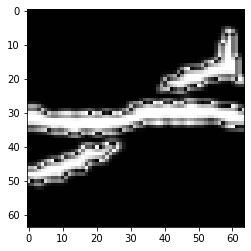

tensor(7)


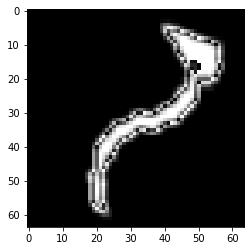

tensor(5)


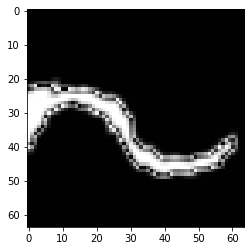

tensor(2)


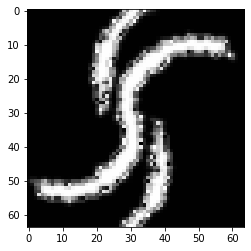

tensor(4)


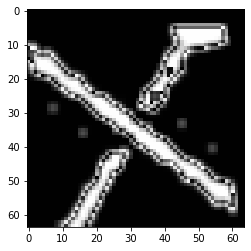

tensor(6)


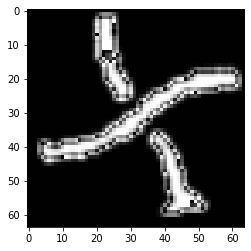

tensor(4)


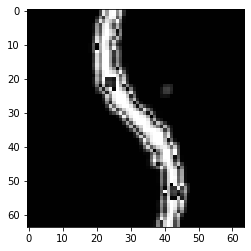

tensor(7)


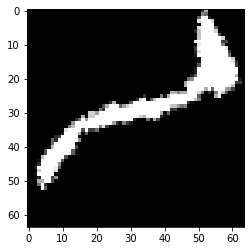

tensor(5)


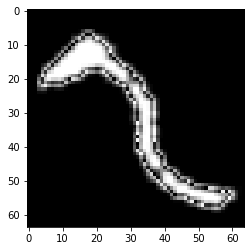

tensor(2)


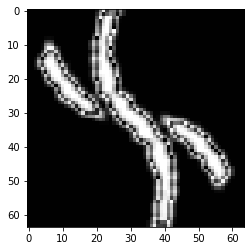

In [116]:
#--------------------------------------------------
# Check if the iterables in dataloader are working
#.--------------------------------------------------

from torchvision.transforms.functional import to_pil_image

# Display image and label.
train_features, train_labels = next(iter(train_dataloader))

train_features.size()

print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {len(train_labels)}")

#img = train_features[10].squeeze()
img = train_features[:10]
label = train_labels[:10]


#to_pil_image is necesarry because the tensor is of size [3,64,64] while plt.imshow take forms [64,64,3]
#Also plt takes numpyArrays and not tensors.
for i in range(len(img)):
    plt.imshow(to_pil_image(img[i]), cmap="gray")
    print(label[i])
    plt.show()



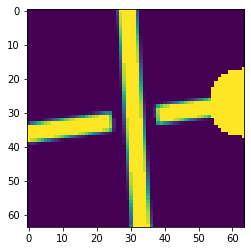

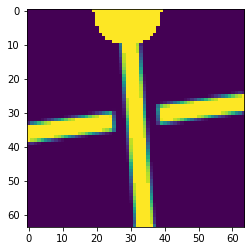

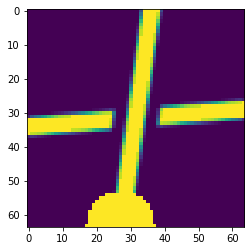

In [91]:
#-------------------------------
# Small cell that generates 5 random corssing
#-------------------------------

N=3

for i in range(N):
    # Initialize a clean, gray background
    img = np.full((WINDOW_SIZE[1], WINDOW_SIZE[0], 3), -1, dtype=np.uint8)
    
    
    # 2. Randomize the crossing type (33% No, 33% Over, 33% Under)
    cross_choice = random.random()
    main_direction, other_direction = random.sample(range(1, 7), 2)
    
    if cross_choice < 0.33:
        # State: NONE
        crossing_type = "None"
        draw_Straight_Line(main_direction) 
            
    elif cross_choice >= 0.33 and cross_choice < 0.66:
        # State: OVER-CROSSING
        crossing_type = "Over"
        draw_over_crossing(main_direction, other_direction)  
    
    else:
        # State: UNDER-CROSSING
        crossing_type = "Under"
        draw_under_crossing(main_direction, other_direction)

        
    #Invert colors, this might be good for recognition
    inv_img = cv2.bitwise_not(img)
    gray_img = cv2.cvtColor(inv_img, cv2.COLOR_BGR2GRAY)
    normalized_img=  gray_img/255.0
    
  
    
    
    plt.imshow(normalized_img)
    plt.show()
    